# INF8775 – Analyse et conception d’algorithmes
# TP2 – Hiver 2026

SEMAAN, Christ, 2186133

NOM, Prénom, 1234567

Note finale :

 <u>**Date limite de remise :**</u>  17 mars 23h59 (Groupe B2), 24 mars 23h59 (Groupe B1)

# Instructions

## Rédaction et remise du rapport

- Ce notebook constitue à la fois le sujet du TP, votre code et votre rapport. Il contient déjà du code pour faciliter vos mesures et l'affichage de vos résultats, ainsi qu'un squelette pour votre rapport.

- Complétez directement le notebook, vous êtes libres de créer de nouvelles cellules de code ou de texte.

- <u>**IMPORTANT**</u> Remettez le fichier du notebook sur Moodle avec le nom `MATRICULE1_MATRICULE2.ipynb`

- Vous pouvez inclure du code trouvé sur Internet, mais vous devez en mentionner la source, sous peine d'être sanctionnés pour plagiat. Cela s'applique aussi au niveau de l'utilisation d'IA pour générer du code. Par contre, veuillez ne pas utiliser d'IA pour rédiger vos analyses, sous peine d'être pénalisé.

## Mise en situation

Ce travail pratique se répartit sur deux séances de laboratoire et porte sur l'analyse et la conception d'algorithmes développés suivant différents patrons de conception afin de résoudre une version simplifiée d'un problème réaliste d'optimisation.


## Description du problème

Dans ce TP, vous allez travailler sur le problème de partition. De manière générale, celui-ci consiste à séparer un ensemble de poids en k ensembles de poids total identique. Dans ce cas-ci, on cherche, à partir d'une liste de valeurs, à obtenir deux listes dont la somme des valeurs est la même.

Par exemple :
- L'exemplaire est : `[6,3,5,2]`
- La seule solution est : `[6,2][5,3]`




## Algorithmes à implanter

Trois algorithmes seront implantés, mettant en pratique des patrons de conception différents :

1. Un algorithme glouton
2. Un algorithme de programmation dynamique
3. Un algorithme d'amélioration locale


## Jeu de données

La classe Problem existe pour simplifier l'interface des différentes fonctions utilitaires. Elle permet de générer des jeux de données avec la méthode `generate_sample` ci-dessous. Elle génère une liste d'une taille donnée contenant des nombres dont la somme est équivalente au total spécifié. Toutes les exemplaires devraient pouvoir être partionner, tant que la somme que vous donnez est pair.

In [1]:
import random
from collections.abc import Iterable, Callable


def simple(size: int, total: int) -> list[int]:
    """Samples generated using a uniform distribution capped at the average value.
    Simplest sample to solve"""
    instance = []
    current_total = 0

    for i in range(size - 1):
        max_val = round((total - current_total) / (size - i))
        value = random.randint(1, max_val)
        current_total += value
        instance.append(value)

    instance.append(int(total - current_total))
    return instance


def uniform(size: int, total: int) -> list[int]:
    """Samples generated using a uniform distribution around the average value"""
    instance = []
    current_total = 0

    for i in range(size - 1):
        avg_val = round((total - current_total) / (size - i))
        value = random.randint(round(avg_val*0.5), round(avg_val*1.5))
        current_total += value
        instance.append(value)
        
    instance.append(int(total - current_total))
    return instance


def normal(size: int, total: int) -> list[int]:
    """Samples generated using a normal distribution"""
    instance = []
    current_total = 0

    for i in range(size - 1):
        avg_val = round((total - current_total) / (size - i))
        value = round(random.normalvariate(avg_val,0.3*avg_val))
        current_total += value
        instance.append(value)
        
    instance.append(int(total - current_total))
    return instance


class Problem():
    def __init__(
        self,
        size: int, 
        total: int, 
        num_samples: int = 5, 
        gen_algo: Callable[[int,int],list[int]] = simple
    ) -> None:
        self.num_samples: int = num_samples
        self.size: int = size
        self.total: int = total
        self.gen_algo = gen_algo

    def generate_sample(self) -> list[int]:
        """Returns a list of the given size containing numbers between 1 and the max_number"""
        left_size = random.randint(2,self.size-1)
        instance = self.gen_algo(left_size,self.total/2)
        instance.extend(self.gen_algo(self.size - left_size,self.total/2))
        random.shuffle(instance)
        return instance

    def generate_dataset(self) -> Iterable[list[int]]:
        """Returns an iterator over as many samples as are described """
        return (self.generate_sample() for _ in range(self.num_samples))

# Implantations et expérimentations

Ces fonctions auxiliaires vous sont fournies pour vérifier l'exactitude de vos algorithmes, mesurer leur performance et afficher vos résultats.

Il est recommandé de prendre le temps de lire et de comprendre le code.

Exécutez la cellule ci-dessous pour pouvoir utiliser les fonctions auxiliaires.

In [2]:
import matplotlib.pyplot as plt
import time
from scipy.stats import linregress


class InvalidSolution(Exception):
    def __init__(self):
        super().__init__("Invalid solution, verify your code.")


class Measure():
    """A wrapper to contain information on taken measures. mae is Mean Absolute Error"""
    def __init__(self, size: int, total: int, mean_time: float, correct_frac:float, mae:float) -> None:
        """Args:
            mae (float): Mean Absolute Error
        """
        self.size = size
        self.total = total
        self.mean_time = mean_time
        self.correct_frac = correct_frac
        self.mae = mae


def make_problems(
    sizes: list[int],
    totals: list[int],
    num_samples: int = 5,
    gen_algo: Callable[[int,int],list[int]] = simple
) -> list[Problem]:
    """Creates problem instances using given sizes and total value"""
    problems: list[Problem] = []
    for size in sizes:
        for total in totals:
            problems.append(Problem(size,total,num_samples,gen_algo))
    return problems


def get_absolute_error(solution: list[list[int]]) -> int:
    """Check if solution is well partitioned """
    target = (sum(solution[0]) + sum(solution[1])) / 2
    return abs(sum(solution[0]) - target)


def get_list_freq(original: list[int]) -> dict[int,int]:
    """Converts a list into a dictionary of frequencies"""
    freq: dict[int,int] = dict()
    for iter in original:
        if iter not in freq.keys():
            freq[iter] = 0
        freq[iter] += 1
    return freq


def verify_solution_format(original: list[int], solution: list[list[int]]) -> bool:
    """Validates if the solution format is correct. This does not guarantee a solution
    with 0 error"""
    if len(solution) != 2:
        return False

    solution = [value for partition in solution for value in partition]

    # Lists must be of equal length
    if len(solution) != len(original):
        return False

    original_freq = get_list_freq(original)
    solution_freq = get_list_freq(solution)
    # Lists must have the same values
    for key in original_freq.keys():
        if key not in solution_freq.keys() or\
            solution_freq[key] != original_freq[key]:
            return False

    # Solution is valid
    return True


def measure(
    procedure: Callable[[list[int]],list[list[int]]],
    sample: list[int],
    time_scale: int = 1000
) -> tuple[int,int]:
    """Returns the time in milliseconds taken to run the procedure as well as the absolute error in a tuple.

    Raises:
        InvalidSolution: If the procedure returns an invalid solution, raises an exception.
    """
    sample = sample.copy()
    start: int = time.time() * time_scale
    solution: list[list[int]] = procedure(sample)
    end: int = time.time() * time_scale
    if not verify_solution_format(sample, solution):
        raise InvalidSolution()
    return (round(end - start), get_absolute_error(solution))


def measure_mean(procedure: Callable[[list[int]],list[list[int]]], prob: Problem, time_scale: int = 1000) -> Measure:
    """Generates multiple samples with the specified parameters and returns the mean time in milliseconds

    Raises:
        InvalidSolution: If one of the samples results in an invalid solution.
    """
    measures = [measure(procedure,sample,time_scale) for sample in prob.generate_dataset()]
    mean_time = sum(iter[0] for iter in measures) / prob.num_samples
    n = len(measures)
    n_correct = len([iter for iter in measures if iter[1] == 0])
    correct_frac = n_correct / n
    mae = 0
    if n_correct != n:
        mae = sum(iter[1] for iter in measures) / (n - n_correct)
    return Measure(prob.size, prob.total, mean_time, correct_frac, mae)


def measure_range(procedure: Callable[[list[int]],list[list[int]]], problems: list[Problem], time_scale: int = 1000) -> list[Measure]:
    """Measures the mean time taken in milliseconds for each size in the given list.

    Raises:
        InvalidSolution: If one of the samples results in an invalid solution.

    Returns:
        A list of Measure instances containing the specifications
        of the problem as well as the mean time.
    """
    return [
        measure_mean(procedure, prob, time_scale)
        for prob in problems
    ]


def display_data_as_table(measures: list[Measure]):
    """Prints a table with the data in the given list of measures"""
    print("{: <20} {: <20} {: <20} {: <20} {: <20}".format("Taille","Somme","Temps moyen (ms)", "Taux de succès", "Erreur absolue moyenne"))
    for measure in measures:
        print("{: <20} {: <20} {: <20} {: <20} {: <20}".format(measure.size, measure.total, measure.mean_time, measure.correct_frac, round(measure.mae, 3)))


### The different tests are below, the names are in french to avoid confusion


def test_de_puissance(
    data: dict[int,int],
    x_label: str,
    y_label: str,
    title: str = "Test de puissance"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    # Log both sets of values
    x = list(data.keys())
    y = list(data.values())

    # Perform the lin regression
    m, b, rvalue, _, _ = linregress(x, y)

    # Estimate the values of y based on the lin regression results
    predicted = [m * iter + b for iter in x]

    # Create the line equation
    line_eq = f"y = {m:.2f}x + {b:.2f}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, predicted, color="red", label=f'Regression linéaire R²={round(rvalue**2,6)}')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()


def test_de_rapport(
    data: dict[int,int],
    x_label: str,
    y_label: str,
    title: str = "Test de rapport"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    x = list(data.keys())
    y = list(data.values())

    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()


def test_de_constantes(
    data: dict[int,int],
    x_label: str,
    y_label: str = "Temps (ms)",
    title: str = "Test de constantes"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    x = list(data.keys())
    y = list(data.values())

    # Perform linear regression
    m, b, rvalue, _, _ = linregress(x, y)

    predicted = [m * iter + b for iter in x]

    # Create the line equation
    line_eq = f"y = {m:.2E}x + {b:.2E}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, predicted, color="red", label=f'Regression linéaire R²={round(rvalue**2,6)}')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

## Partie 1 : Algorithme glouton (5 points)

<u>**Question 1 :**</u> Implantez un algorithme suivant le patron de conception glouton.

Il est normal que le glouton ne retourne pas toujours la solution optimale. Vous pouvez voir l'erreur obtenue et le taux de réponse optimal avec les fonctions de mesure.

Tentez de rendre votre implantation la plus performante possible en évitant des calculs inutiles.

### Analyse asymptotique

<u>**Question 2 :**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Expliquez

*Insérer votre réponse ici*

### Mesures

<u>**Question 3 :**</u> Rapportez dans un tableau les temps d'exécution moyens avec les fonctions auxiliaires `measure_range` et `display_data_as_table`.

### Validation empirique

<u>**Question 4 :**</u> Servez-vous de vos temps d'exécution pour confirmer et/ou préciser l'analyse asymptotique théorique de vos algorithmes avec la méthode hybride de votre choix. 

La méthode peut varier d'un algorithme à l'autre. Assurez vous de présenter suffisamment de graphiques pour supporter crédiblement vos conclusions et justifiez leur pertinence. Il ne faut pas réaliser tout les types de tests. Choisissez seulement les plus pertinents pour votre analyse. Et ce pour les 3 algorithmes.

*Insérer votre réponse ici*

## Partie 2 : Algorithme de programmation dynamique (5 points)

Une solution au problème de partition requiert nécessairement que la somme des valeurs dans chacune des partitions soit la moitié de la somme de l'exemplaire complet. Ainsi, il suffit de trouver une ensemble de valeurs égalisant la moitié de la somme totale pour trouver une réponse valide. Toutes les autres valeurs formeront la seconde partition.

Considérez un sous ensemble *X*. Les membres de *X* peuvent être combinés pour obtenir différentes valeurs. En ajoutant une nouvelle variable *y* au sous-ensemble, pour chacune des valeurs atteignables précédemment, il est possible d'atteindre la valeur + *y*.

Ainsi, l'algorithme de programmation dynamique répondant à ce problème consiste à explorer les valeurs obtenables à partir d'un sous-ensemble de valeurs en ajoutant progressivement les valeurs de l'exemplaire jusqu'à obtenir un sous-ensemble dont la valeur combinée est la moitié de la valeur de l'instance.

<u>**Question 1 :**</u> Implantez l'algorithme de programmation dynamique.

In [3]:
#N.B: Le code est généré par ChatGPT
from typing import List

def dynamic(sample: list[int]) -> list[list[int]]:
    """
    Programmation dynamique pour le problème de partition (2 ensembles).
    Idée: trouver un sous-ensemble de somme target = sum(sample)//2.
    
    Retour:
        [A, B] où A et B contiennent exactement les éléments de sample (mêmes fréquences).
        Si une partition parfaite existe (erreur=0), elle est trouvée.
        Sinon, on retourne la meilleure somme <= target (erreur minimale côté <=target).
    """
    n = len(sample)
    total = sum(sample)
    target = total // 2

    # dp[s] = 1 si la somme s est atteignable avec un sous-ensemble des premiers éléments traités
    dp = bytearray(target + 1)
    dp[0] = 1

    # Pour reconstruire la solution :
    # parent_sum[s] = somme précédente (s - valeur_choisie)
    # parent_idx[s] = index de l'élément utilisé pour atteindre s
    parent_sum = [-1] * (target + 1)
    parent_idx = [-1] * (target + 1)

    # Remplissage DP (boucle s décroissante => chaque élément utilisé au plus une fois)
    for i, val in enumerate(sample):
        if val <= 0:
            # vos données sont positives; on ignore proprement le cas "bizarre"
            continue
        if val > target:
            # impossible de participer à une somme <= target
            continue

        for s in range(target, val - 1, -1):
            if not dp[s] and dp[s - val]:
                dp[s] = 1
                parent_sum[s] = s - val
                parent_idx[s] = i

    # On veut idéalement target; sinon la meilleure somme atteignable <= target
    if dp[target]:
        best = target
    else:
        best = 0
        for s in range(target, -1, -1):
            if dp[s]:
                best = s
                break

    # Reconstruction du sous-ensemble choisi via les parents
    chosen = [False] * n
    s = best
    while s != 0:
        i = parent_idx[s]
        if i == -1:
            # Sécurité: ne devrait pas arriver si dp est cohérent
            break
        chosen[i] = True
        s = parent_sum[s]

    part1 = [sample[i] for i in range(n) if chosen[i]]
    part2 = [sample[i] for i in range(n) if not chosen[i]]
    return [part1, part2]


# Petit test rapide (optionnel)
# print(dynamic([6,3,5,2]))  # ex: [[6,2],[3,5]] (ou l'inverse)
        


### Analyse asymptotique

<u>**Question 2 :**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Expliquez

On choisit comme opération baromètre le test 'if not dp[s] and dp[s-val]' dans la boucle interne.
Chaque valeur val (il y en a n) parcourt s de target à val, donc elle effectue au plus (target - val + 1) itérations par élément.
Donc la complexité du temps sera de l'ordre Θ(n·target) = Θ(n·(S/2)) = Θ(nS) où S désigne la somme totale des éléments de l’instance (donc S = sum(sample)).

### Mesures

<u>**Question 3 :**</u> Rapportez dans un tableau les temps d'exécution moyens avec les fonctions auxiliaires `measure_range` et `display_data_as_table` **C'est attendu que cet algorithme soit beaucoup plus lent que le glouton. Vous n'avez pas besoin de mesurer sur des exemplaires aussi gros.**

In [4]:
#N.B: Le code est généré par ChatGPT
# --- Mesures

# 1) Paramètres de mesure
sizes_dp  = [20, 30, 40, 50, 60]          # tailles de listes (petites/modérées)
totals_dp = [200, 400, 600, 800, 1000]    # sommes totales (pairs recommandés)

# 2) Génère les problèmes (num_samples = nb d'exemplaires par (size,total))
problems_dp = make_problems(
    sizes=sizes_dp,
    totals=totals_dp,
    num_samples=5,      # tu peux mettre 3 si c’est trop long
    gen_algo=simple     # simple est le plus stable; tu peux tester uniform/normal plus tard
)

# 3) Mesure les temps moyens + taux de succès + erreur moyenne
measures_dp = measure_range(dynamic, problems_dp)

# 4) Affiche le tableau demandé
display_data_as_table(measures_dp)

Taille               Somme                Temps moyen (ms)     Taux de succès       Erreur absolue moyenne
20                   200                  0.0                  1.0                  0                   
20                   400                  0.6                  1.0                  0                   
20                   600                  0.4                  1.0                  0                   
20                   800                  0.0                  1.0                  0                   
20                   1000                 2.4                  1.0                  0                   
30                   200                  0.4                  1.0                  0                   
30                   400                  0.4                  1.0                  0                   
30                   600                  0.8                  1.0                  0                   
30                   800                  1.2        

### Validation empirique

<u>**Question 4 :**</u> Servez-vous de vos temps d'exécution pour confirmer et/ou préciser l'analyse asymptotique théorique de vos algorithmes avec la méthode hybride de votre choix.

La méthode peut varier d'un algorithme à l'autre. Justifiez les choix ici et avec des graphiques.

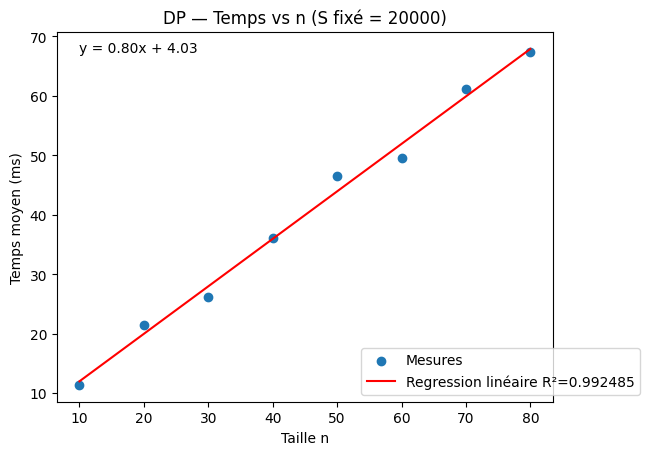

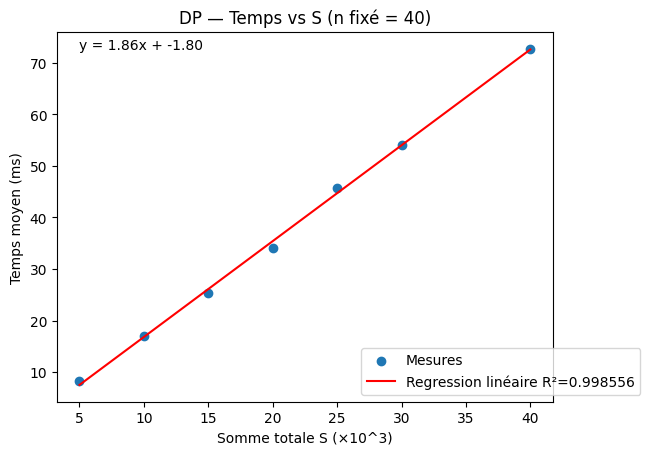

In [ ]:
#N.B: Le Code est généré par ChatGPT
# DP — varier n, S fixé (grand) pour obtenir des temps > ~10ms
total_fix = 20000  # augmente si encore trop petit, ex: 50000

sizes = [10, 20, 30, 40, 50, 60, 70, 80]
problems_n = make_problems(sizes=sizes, totals=[total_fix], num_samples=10, gen_algo=simple)
measures_n = measure_range(dynamic, problems_n)

data_time_vs_n = {m.size: m.mean_time for m in measures_n}
test_de_puissance(data_time_vs_n, "Taille n", "Temps moyen (ms)", f"DP — Temps vs n (S fixé = {total_fix})")

# DP — varier S, n fixé
n_fix = 40
totals = [5000, 10000, 15000, 20000, 25000, 30000, 40000]  # pairs

problems_S = make_problems(sizes=[n_fix], totals=totals, num_samples=10, gen_algo=simple)
measures_S = measure_range(dynamic, problems_S)

#data_time_vs_S = {m.total: m.mean_time for m in measures_S}
#test_de_puissance(data_time_vs_S, "Somme totale S", "Temps moyen (ms)", f"DP — Temps vs S (n fixé = {n_fix})")
data_time_vs_S_k = {m.total/1000: m.mean_time for m in measures_S}  # S en milliers
test_de_puissance(data_time_vs_S_k, "Somme totale S (×10^3)", "Temps moyen (ms)",
                 f"DP — Temps vs S (n fixé = {n_fix})")

Pour $S$ fixé à 20000, le graphe Temps vs n est très bien expliqué par une droite de pente 0.80 avec ${R^2 \approx 0{,}992}$, ce qui indique une complexité de $\Theta(n)$.
Pour n fixé à 40, le graphe Temps vs S peut être expliqué par une droite de pente 0.00186 (1.86/1000 parce que S est en milliers) avec ${R^2 \approx 0{,}999}$, donc, quand n est constant, la complexité du temps est de $\Theta(S)$.
En combinant ces deux résultats qui découlent d'une variation d’un paramètre à la fois, on conclut que le temps suit $\Theta(nS)$, ce qui confirme l’analyse théorique de l’algorithme dans laquelle on a montré que sa complexité était de l'ordre $\Theta(n\cdot target)$ avec $target=S/2$.


## Partie 3 : Algorithme d'amélioration locale (5 points)

Cet algorithme explore le voisinage de solutions non optimales. En partant d’une solution, celle-ci est améliorée en modifiant une ou plusieurs de ses assignations. Vous pouvez prendre
comme critère d’arrêt un nombre maximum d’itérations et comme fonction de coût `get_absolute_error`.

<u>**Question 1 :**</u> Implantez un algorithme suivant le patron de conception d'amélioration locale.

### Analyse asymptotique

<u>**Question 2 :**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Expliquez

*Insérer votre réponse ici*

### Mesures

<u>**Question 3 :**</u> Rapportez dans un tableau les temps d'exécution moyens avec les fonctions auxiliaires `measure_range` et `display_data_as_table`. Vous pouvez comparer vos résultats à ceux sans l'amélioration locale pour voir l'amélioration.

### Validation empirique

<u>**Question 4 :**</u> Servez-vous de vos temps d'exécution pour confirmer et/ou préciser l'analyse asymptotique théorique de vos algorithmes avec la méthode hybride de votre choix.

La méthode peut varier d'un algorithme à l'autre. Justifiez les choix ici et avec des graphiques.

*Insérer votre réponse ici*

# Évaluation de la consommation énergétique (1 point)

Dans le cadre de ce TP, nous voulons vous sensibiliser à la consommation énergétique de vos algorithmes. Pour ce faire, nous vous fournissons une librairie que vous pouvez utiliser pour évaluer l'énergie nécessaire à la complétion de votre algorithme (https://mlco2.github.io/codecarbon/). Appelez chacun de vos algorithmes ci-bas avec les mêmes exemplaires et comparez le résultat obtenu par chacun.

In [ ]:
#Commande pour installer la librairie
#!pip install codecarbon

In [ ]:
from codecarbon import EmissionsTracker
try:
    tracker = EmissionsTracker(measure_power_secs=5, tracking_mode="process")

    tracker.start_task("glouton")
    # TODO Appel glouton
    tracker.stop_task()

    tracker.start_task("dynamic")
    # TODO Appel dynamique
    tracker.stop_task()

    tracker.start_task("recherche")
    # TODO Appel recherche
    tracker.stop_task()
finally:
    _ = tracker.stop()

Les résultats de l'exécution du code ci-haut devraient apparaître dans un fichier csv. Rapportez les réusltats et commentez les. Vous pouvez trouver une explication de la sortie dans la documentation qui est présente au lien ci-haut.

*Insérer votre réponse ici*

# Conclusion et synthèse (2 points)

Résumez brièvement les principales observations issues de vos analyses et indiquez dans quelles situations chacun des algorithmes étudiés serait le plus approprié. Justifiez vos conclusions à l’aide des résultats obtenus.

*Insérer votre réponse ici*

## Autres critères (2 pts)
 Qualité du code / 1 pt

Présentation générale / 1 pt

- Concision
- Qualité du français

Pénalité retard
- -1 pt / journée de retard, arrondi vers le haut. Les TPs ne sont plus acceptés après 3 jours.